# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [4]:
plans.head(5)# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
users.head(5)# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
usage.head(5)# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print("Valores Nulos", users.isna().sum())
print("Proporcion de valores nulos", users.isna().mean())

Valores Nulos user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporcion de valores nulos user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
print("Cantidad de valores nulos para usage por columna", usage.isna().sum())
print("cantidad total de valores nulos para usage:",usage.isna().mean())# cantidad de nulos para usage

Cantidad de valores nulos para usage por columna id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
cantidad total de valores nulos para usage: id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint: En el caso del dataframe de users, la cantidad de nulos en city es viable imputarla (11.72% de NA) y en el caso de churn_date (88.35% de NA) es viable eliminarla ya que la mayoria de los datos son nulos y solo nos dice en que fecha el usuario abandono la compañia es decir en que momento dejo de ser el cliente y como la mayoria de los usuarios siguen activos (11.65%) contratando el servicio no es necesario mantener ese dato. En el caso del dataframe de duration y length simplemente se refiere a que tipo de uso se le esta dando servicio estan empleando, si es una llamada o un mensaje de texto y que duracion tiene. 
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
display("Resumen estadistico de user_id",users["user_id"].describe()),
display("Resumen estadistico de age",users["age"].describe())# explorar columnas numéricas de users

'Resumen estadistico de user_id'

count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64

'Resumen estadistico de age'

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

- La columna `user_id` Los usuarios empiezan en el 10,000 y terminan en el 13,999 completando los 4000 usuarios en el sistema... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` hay un valor sentinela de -999 que habria que cambiar por nulo y despues imputar, probablemente por la mediana o el promedio que es de 33 años y el valor maximo es de 79 años que si bien es algo alto es un valor creible y nada fuera de un valor sentinela. Nuestra media de edad de nuestro IQR es de 31  ...

In [14]:
display("Resumen estadistico de id",usage["id"].describe()),
display("Resumen estadistico de user_id",usage["user_id"].describe())# explorar columnas numéricas de usage

'Resumen estadistico de id'

count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64

'Resumen estadistico de user_id'

count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64

- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas, En el caso de ID empieza con el numero 1 y termina en el 40,000 esto significa que cada llamada o mensaje esta registrada con un id diferente sin importar si el user_id se repite, el ID es unico y diferente. En el caso de user_id nos dice que es el mismo que el user_id de la tabla users ya que empieza en el 10,000 y termina en el 13,999 pero a diferencia de la otra tabla aqui se repite el user_id indicando que un mismo usuario realizo mulitples llamadas o mensajes.

In [15]:
# explorar columnas categóricas de users
columnas_user =users[['city','plan']]
columnas_user.value_counts()


city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

- La columna `city` aparte de los valores nulos que vimos en la tabla de NA, vemos que hay 65 personas del plan basico que en lugar de poner su ciudad pusieron un signo "?" y 31 personas del plan premium que dejaron un espacio vacio. Estos valores se podrian imputar con las ciudades mas populares de cada plan e incluirlas en el mismo proceso de imputacion que los valores nulos 
- La columna `plan` Vemos que las ciudades se repiten y de momento no hay ciudades con el mismo nombre pero escrito de forma distinta esto nos ahorara un paso en el proceso de filtrado y analisis de datos posterior

In [16]:
# explorar columna categórica de usage
usage['type'].value_counts() # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna `type`  Mensajes de texto representa el (55.23%) y las llamadas representan el (44.77%). La mayoria de los usuarios manda mensajes de texto sobre las personas que hacen llamadas, aun asi no es una diferencia grande solo representa el 10.46%


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  En las columnas age sentinels y en city valores invalidos
- ¿Qué acción tomarías?  En age reemplazar esos valores por mediana o promedio y en city reemplazar por ciudad mas frecuente 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"],errors="coerce") # completa el código

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors="coerce")# completa el código

In [19]:
users['reg_date'].dt.year.value_counts()# Revisar los años presentes en `reg_date` de users


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, Hay valores parecidos en el año 2022,2023,2024 y hay 40 registros en el año 2026, pero no hay datos del 2025 

In [20]:
usage['date'].dt.year.value_counts()# Revisar los años presentes en `date` de usage


2024.0    39950
Name: date, dtype: int64

En `date`, solo hay registros del año 2024, asi que tendre que filtrar los datos de users a que solo sean del 2024 para que coincida con los de usage  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? aparecen datos del 2026 (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas? borrare los datos para que no afecte al analisis aun asi solo utilizare los 2024 ya que son los que coinciden con los del otro año

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median() 
users['age'] = users['age'].replace(-999, age_mediana) 

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users['city']=users['city'].replace("?", pd.NA)

# Verificar cambios
users['city'].unique()

array(['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [23]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year==2026, 'reg_date']=pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [25]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
La cantidad es minima menos del 1%, se pueden eliminar esos datos

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[["is_text","is_call","duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Renombrar columnas
usage_agg=usage_agg.rename(columns={"is_text":"cant_mensajes","is_call":"cant_llamadas","duration":"cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users,usage_agg, on=['user_id'], how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [30]:
user_profile['plan'].value_counts(normalize=True)# Distribución porcentual del tipo de plan


Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

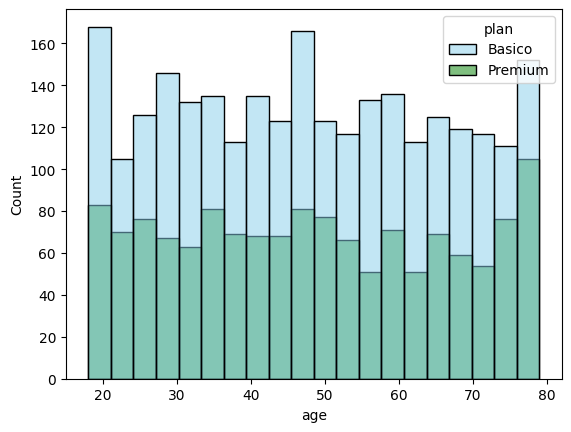

In [35]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile,x='age', hue='plan', bins=20,palette=['skyblue','green'])
plt.show()

💡Insights Vemos que hay una distribucion ligera hacia la izquierda, ya que el promedio de edad es de 33 años, que hay dos grupos cercanos a los 50 y arriba de los 80 años que tambien son relevantes. Hay mayor predominancia hacia a gente entre 18 y 35 años.
- Distribución hacia la izquierda

<AxesSubplot:xlabel='cant_mensajes', ylabel='Count'>

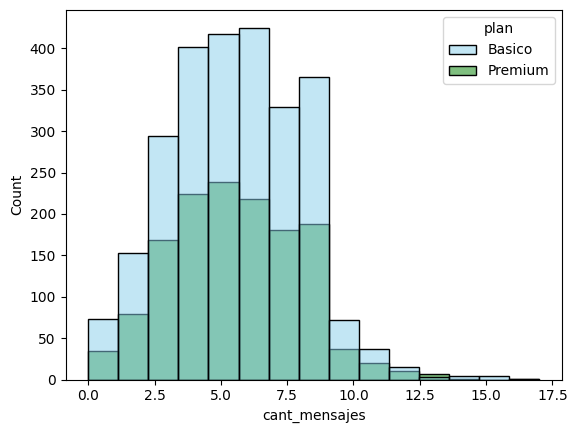

In [38]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile,x='cant_mensajes', hue='plan', bins=15, palette=['skyblue','green'])

# 💡Insights: 
- La mayoria de las personas envia de 2 mensajes a 8 mensajes, la tabla distribucion es hasta la izquierda, teniendo muy pocas personas que escriben mas de 10 mensajes 

<AxesSubplot:xlabel='cant_llamadas', ylabel='Count'>

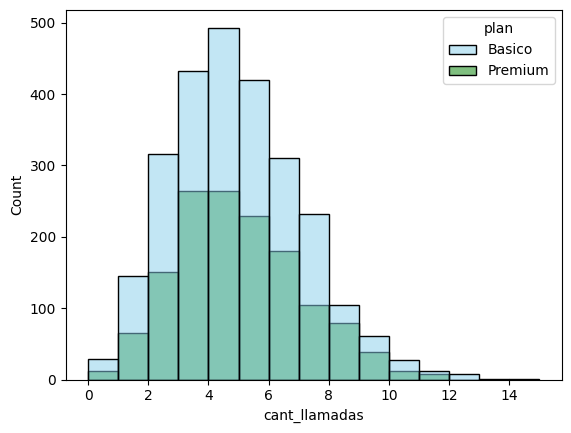

In [39]:
sns.histplot(data=user_profile,x='cant_llamadas', hue='plan', bins=15, palette=['skyblue','green'])# Histograma para visualizar la cant_llamadas


💡Insights: 
- Distribución hacia la izquierda, con el grueso de los usuarios llamando de 3 a 6 veces y muy pocas personas marcando mas de 10 veces.

<AxesSubplot:xlabel='cant_minutos_llamada', ylabel='Count'>

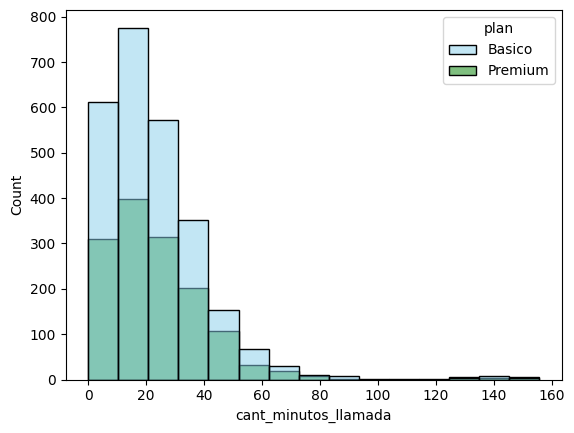

In [42]:
sns.histplot(data=user_profile,x='cant_minutos_llamada', hue='plan', bins=15, palette=['skyblue','green'])# Histograma para visualizar la cant_minutos_llamada


💡Insights: 
- Con una distribucion hacia la izquierda la mayoria de los usuarios dura entre 0 a 30 minutos en una llamada, con pocas personas teniendo una llamada de mas de 50 minutos y outliers de mas de 130 minutos

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

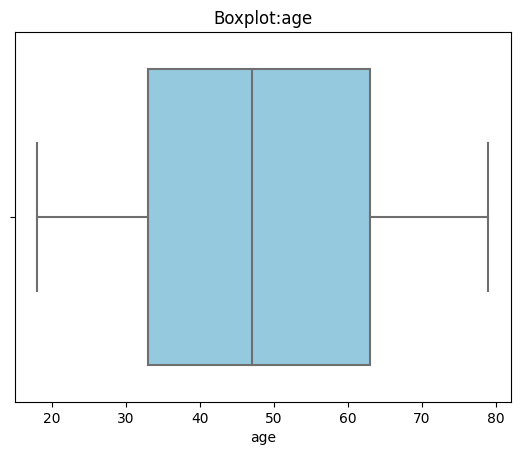

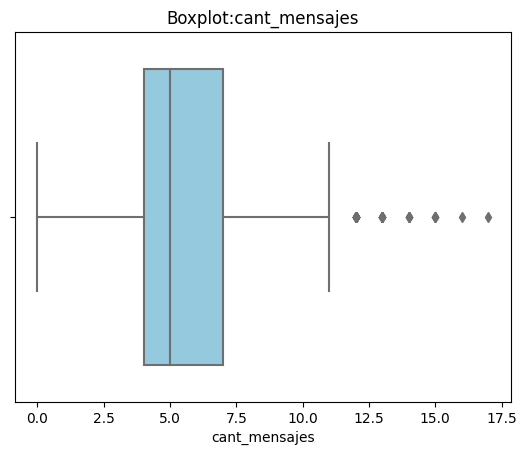

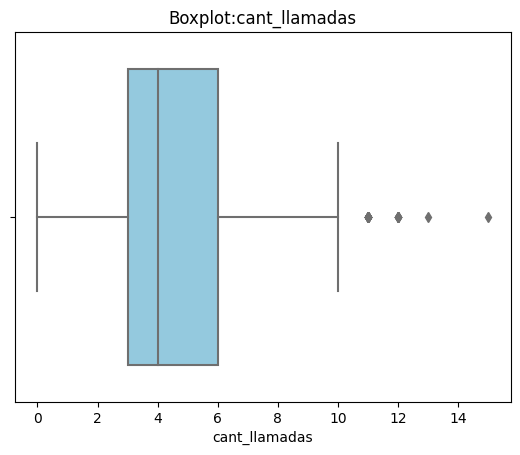

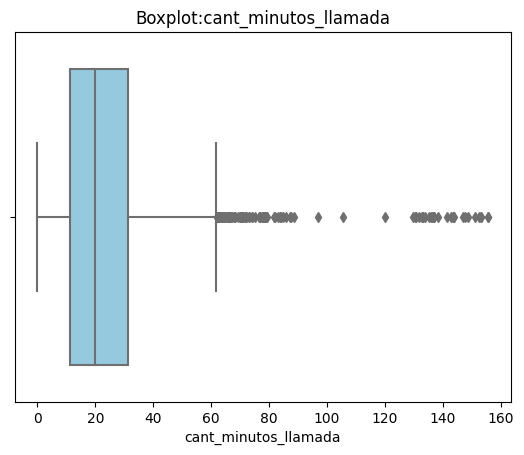

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_numericas:
    sns.boxplot(x=user_profile[col],color='skyblue')
    plt.title(f'Boxplot:{col}')
    plt.show()


💡Insights: 
- Age: No presenta outliers debido a que solo tenemos a una persona de 79 años que seria nuestro valor maximo pero hay mas personas que estan dentro de esa edad(presenta o no outliers)
- cant_mensajes: presenta un outlier que seria una persona que mando 17 mensajes cuando nuestro Q3 es de 7 mensajes
- cant_llamadas: presenta un outlier ques eria una persona que marco 15 veces cuando nuestro Q3 es de 6 llamadas
- cant_minutos_llamada: Hay outliers, hay bastantes valores por fuera de los bigotes de la grafica, aunque nuestro IQR sea de 20.29 minutos, hay usuarios que superaron los 130 min y uno que llego hasta los 155 minutos

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']
for col in columnas_limites:
    Q1=user_profile[col].quantile(0.25)
    Q3=user_profile[col].quantile(0.75)
    IQR=Q3-Q1
    extremo_inferior=(Q1-1.5)*IQR
    extremo_superior=(Q3+1.5)*IQR
    print(f'IQR de {col}',IQR) 
    print(f'Extremo inferior de {col}', extremo_inferior)
    print(f'Extremo superior de {col}', extremo_superior)
   


IQR de cant_mensajes 3.0
Extremo inferior de cant_mensajes 7.5
Extremo superior de cant_mensajes 25.5
IQR de cant_llamadas 3.0
Extremo inferior de cant_llamadas 4.5
Extremo superior de cant_llamadas 22.5
IQR de cant_minutos_llamada 20.295
Extremo inferior de cant_minutos_llamada 195.2379
Extremo superior de cant_minutos_llamada 668.0099250000001


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? mantendria los outliers debido a que es son datos reales de comportamiento de usuario
- cant_llamadas: mantener o no outliers, porqué? mantendria los outliers debido a que son datos reales de comportamiento del usuario
- cant_minutos_llamada: mantener o no outliers, porqué? mantendria los valores atipicos leves y eliminaria los valores atipicos extremos ya que no representan el grueso de los usuarios. lo representativo se encuentra dentro de la grafica de caja y cercano a los bigotes superiores

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
user_profile['grupo_uso']=np.select([(user_profile['cant_mensajes']<5) & (user_profile['cant_llamadas']<5) ,(user_profile['cant_mensajes']<10) & (user_profile['cant_mensajes']<10)],['Bajo Uso','Uso medio'],default="Alto Uso") # Crear columna grupo_uso


In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Uso medio
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto Uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo Uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
user_profile['grupo_edad']=np.select([(user_profile['age']<30) , (user_profile['age']<60)], ['Joven','Adulto'],default="Adulto Mayor") # Crear columna grupo_edad


In [40]:
# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Uso medio,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto Uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo Uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

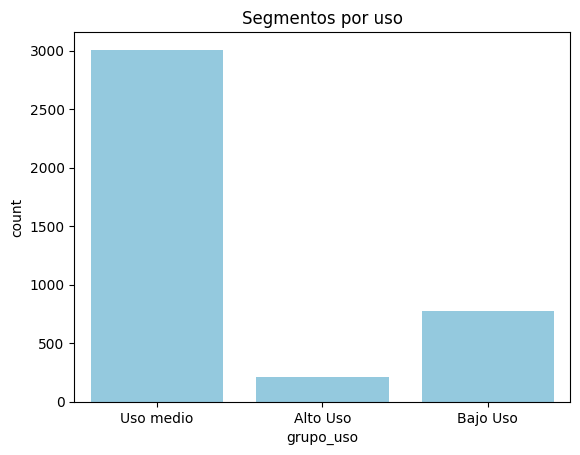

In [41]:


# Visualización de los segmentos por uso
sns.countplot(x=user_profile['grupo_uso'],color='skyblue')
plt.title("Segmentos por uso")
plt.show()


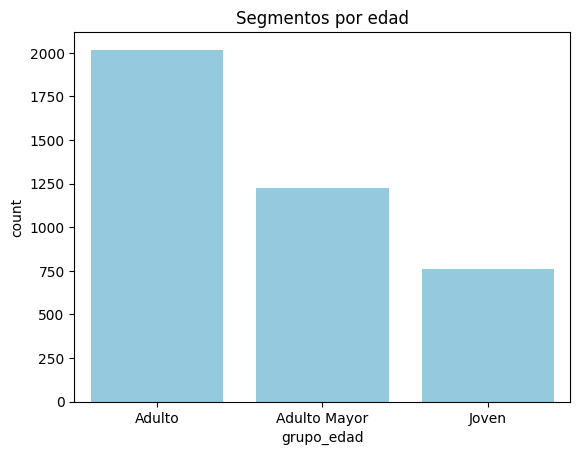

In [42]:
# Visualización de los segmentos por edad
sns.countplot(x=user_profile['grupo_edad'],color='skyblue')
plt.title("Segmentos por edad")
plt.show()

In [43]:
user_profile['grupo_uso'].value_counts()

Uso medio    3009
Bajo Uso      778
Alto Uso      213
Name: grupo_uso, dtype: int64

In [44]:
user_profile['grupo_uso'].value_counts(normalize=True)

Uso medio    0.75225
Bajo Uso     0.19450
Alto Uso     0.05325
Name: grupo_uso, dtype: float64

In [45]:
user_profile['grupo_edad'].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [46]:
user_profile['grupo_edad'].value_counts(normalize=True)

Adulto          0.5045
Adulto Mayor    0.3055
Joven           0.1900
Name: grupo_edad, dtype: float64

In [47]:
usuarios_altos=user_profile[user_profile['cant_minutos_llamada']>62]
usuarios_altos['user_id'].nunique()

109

In [48]:
print("% de Usuarios Altos:", (109/4000)*100)

% de Usuarios Altos: 2.725



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmente los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
Tenian valores fuera de rango en cuanto a fecha ya que contaban con 40 registros del año 2026 pero no contaban con registros del año 2025, asi que se eliminaron ya que solo representaban el 1% de los valores totales de usuarios, despues se unifico datasets para que solo quedaran las columnas mas importantes, creando nuevas para que nos dieran mas informacion segmentada de los usuarios.
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Se segmento por edad y por tipo de uso, en cuanto a la edad se clasifico por tres categorias : Joven (<30 años), Adulto (<60 años) y Adulto mayor(=>60 años), en la segmentacion por uso de la cantidad de mensajes y llamadas se segmento de la siguiente forma: Bajo Uso (<5 llamadas y   <5mensajes), Uso Medio (<10 llamadas y <10 mensajes) y Uso alto (>10 llamadas y >10 mensajes)
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
Uso medio representando a 3000 (75.25%) usuarios de 4000 y el segmento de edad mayoritario es Adulto con 2018 (50.45%) usuarios de 4000 
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Hay pocos usuarios que sean de Alto Uso solo el 5% del total de usuarios y hay solo un 19% de usuarios Jovenes

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
me enfocaria mas en los planes de los jovenes por que son el grupo minoritario y que necesita mas oportunidad de crecimiento, campañas mas centradas en el publico joven (redes sociales, planes mas adaptados a paquetes de internet y no tanto a mensajes y llamadas que no se suele utilizar tanto, planes asociados a estudiantes y potenciando el sector mayoritario de adultos podria ser planes que incluyan equipos o planes familiares para poder atraer a mas usuarios teniendo como canal a un usuario que sea fiel ya que hay muy pocos usuarios que dejen de usar o esten contratando el servicio)
✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Registros de Usuarios en el año 2026
- Una gran disparidad entre los datos de la cantida de minutos de las llamadas que efectuan los usuarios.

🔍 **Segmentos por Edad**
- El segmento de los adultos es el mayoritario (75.25%)
- El segmento de los jovenes (19%) tiene muy baja participacion

📊 **Segmentos por Nivel de Uso**
- Los usuarios en su mayoria son de "Uso Medio" representando el 75% del total de usuarios, esto quiere decir que dan un uso moderado del servicio, esto nos da un panorama de en que tipo de usuarios se puede esperar en un futuro crecimiento de la compañia y poder estimar mejor los gastos e inversiones de ser necesario para poder operar con mejores margenes.
- Los usuarios de "Bajo Uso" y "Alto Uso" representan menos del 30% del total de usuarios y en especifico los de uso Alto representan solo el 5.3% del total de usuarios esto en parte es positivo ya que no se saturan los servicios por estos usuarios de alta demanda, en caso de que se tengan mas usuarios de este tipo podria adaptarse planes para que se puedan subirles los precios o aumentarles la tarifa a partir de ciertas condiciones de uso o en su debido caso se le podrian ofrecer servicios mas costosos que compensen el uso fuera de habitual que le dan.

➡️ Esto sugiere que:
Nuestro sector mas fuerte son los adultos y que la mayoria de los usuarios hacen un uso medio del servicio, que tenemos un area de oportunidad con los jovenes para poder expandir ese mercado, hay una cantidad pequeña de 2.75% de usuarios que hacen llamadas por encima de 62 minutos cuando el promedio es de 23 min (solo para tener el dato en cuenta) ya que tenemos en cuenta los usuarios de Alto Uso como un consumo bajo de alrededor del 5% pero no se toma muy en cuenta de los usuarios que usan el servicio de manera extendida en una llamada, tambien es un factor que no deberia pasar desapercibido aunque sea un numero bajo.


💡 **Recomendaciones**
- Es importante mantener y poder diseñar estrategias para ese sector de consumidores y tambien el poder atraer otros clientes del mismo segmento pero de la competencia refiriendonos al uso medio y al sector de edad de Adultos.
-  En cuanto el sector de edad de los Jovenes se deberian plantear campañas o planes dedicados en ese sector debido a que estamos perdiendo a un parte grande del mercado     

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`